In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
import pickle
import torch

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.experiments import ModelEvaluator, Experiment
from scripts.modelClassGPU import ConfiModel
data_path = 'P:/3026008.02/MNLE'

device is : cpu


## 1. Whether the MNLE results look alike the model

In [2]:
m_id = 1
exp_name='MNLE_test'
targetname = exp_name + '_model_' + str(m_id)
sim_agg_data_path = os.path.join(data_path, exp_name, 'model_' + str(m_id), 'agg_data')
with open(os.path.join(sim_agg_data_path, targetname + '_agg.pickle'), 'rb') as handle:
    all_sim_dat, all_theta = pickle.load(handle)

# for one condition and one theta
t_i = all_theta[torch.randperm(all_theta.size(0))[0], :]
theta = t_i[:-4]
cond = t_i[ -4:].unsqueeze(0)

In [13]:
theta

tensor([ 2.7466,  5.5775,  9.6656, 19.3396,  2.7201, 46.3655,  0.5717,  0.6234,
         0.1885,  0.2004,  0.2349])

In [3]:
exp = Experiment(exp_name, cluster=False)
model = ConfiModel(m_id, exp.exp_config)

In [4]:
# first, the likelihood landscape from model simulation
dat_m_sim = model.run_simulation(inputs = theta, trialConds=np.repeat(cond, repeats=50000, axis=0))

In [5]:
estimator = exp.get_MNLE_estimator(m_id)

c:\Users\wenlou\.conda\envs\cluster\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
m:\1confiProj\scripts\utils.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_on

In [ ]:
ci_lin = np.linspace(-0.1, 31, 100)
sr_lin = np.linspace(-31, 31, 100)
conf_lin = np.linspace(-0.1, 101, 100)/100

ci_grid, sr_grid, conf_grid = np.meshgrid(ci_lin, sr_lin, conf_lin)
n_points = ci_grid.size   # or sr_grid.size or conf_grid.size (all equal)

comb_0 = np.column_stack((
    sr_grid.flatten(),
    ci_grid.flatten(),
    conf_grid.flatten(),
    np.repeat(0, n_points)   # match total number of points
))

comb_1 = np.column_stack((
    sr_grid.flatten(),
    ci_grid.flatten(),
    conf_grid.flatten(),
    np.repeat(1, n_points)
))

x_o = torch.tensor(np.concatenate((comb_0, comb_1))).to(torch.float32)
choice_labels = x_o[ :, -1].to(torch.int).cpu().numpy()

eps=1e-3
CTE = 1/10000
x_o = x_o.reshape((1, x_o.shape[0], x_o.shape[1]))
n_points = x_o.shape[1]   # number of grid points
t_i_expanded = t_i.repeat(n_points, 1)  # expand condition to match
log_liks = estimator.log_prob(x_o, condition=t_i_expanded).detach().numpy()
#log_liks = estimator.log_prob(x_o, condition=t_i).detach().numpy()  #take log prob from MNLE
log_liks = np.exp(log_liks)*(1-eps) + eps*CTE  # add contaminants

In [ ]:
c = 1  # or 0
plot_p = log_liks[choice_labels == c]


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1 but size of corresponding boolean axis is 2000000

In [25]:
# Pick a slice at middle conf index
idx = len(conf_lin) // 2

plt.figure(figsize=(8, 6))
plt.contourf(ci_lin, sr_lin, log_liks[:, :, idx].T, levels=50, cmap="viridis")
plt.colorbar(label="Likelihood")
plt.xlabel("ci")
plt.ylabel("spa")
plt.title(f"Likelihood slice at conf ≈ {conf_lin[idx]:.2f}")
plt.show()

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

<Figure size 800x600 with 0 Axes>

C:\Users\wenlou\AppData\Local\Temp\ipykernel_19780\2890997239.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(dat_m_sim[:,5], dat_m_sim[:,4], dat_m_sim[:,-1], c='blue', cmap='viridis', s=1, alpha=0.2)


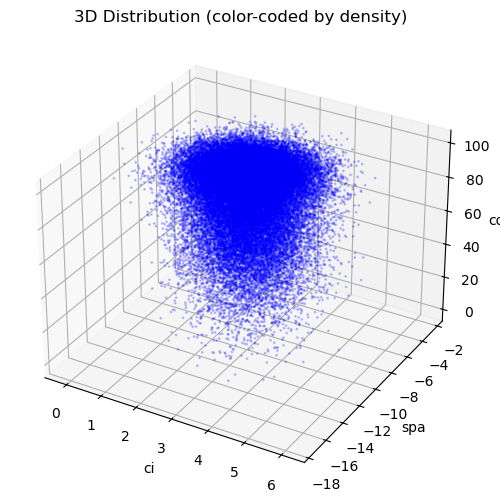

In [8]:
# select data
c=1
dat_plot = dat_m_sim[dat_m_sim[:, -2] ==c]

# Create grid
ci_lin = np.linspace(-0.1, 31, 1000)
sr_lin = np.linspace(-31, 31, 1000)
conf_lin = np.linspace(-0.1, 101, 1000)

ci_grid, sr_grid, conf_grid = np.meshgrid(ci_lin, sr_lin, conf_lin)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(dat_m_sim[:,5], dat_m_sim[:,4], dat_m_sim[:,-1], c='blue', cmap='viridis', s=1, alpha=0.2)

ax.set_xlabel("ci")
ax.set_ylabel("spa")
ax.set_zlabel("conf")
plt.title("3D Distribution (color-coded by density)")

# Add colorbar
# cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
# cbar.set_label("Density")

plt.show()


## 2. Compare the QML with MNLE (2 million simulation)

In [8]:
m_id = 1
sub_id=3

In [9]:
ev = ModelEvaluator('MNLE_test', cross_test=True)
test = ev.test_model_exp(m_id = m_id)

Execution time: 0.538074 seconds


In [10]:
df_loss = ev.get_loss(m_id=m_id , sub_id=sub_id, save = True)

KeyboardInterrupt: 

In [8]:
df_loss

,run_id,model_id,sub_id,nfold,train_nll,est_params,init_params,runtime,success,test_nll
0,20250910_215705,1,2,0,11964.339844,"[1.10898595271752, 7.202481523156166, 5.792782...","[0.7789176865827515, 8.584393067246019, 3.4760...",1.228221,True,20237.300907
1,20250910_215708,1,2,0,11964.005859,"[1.1106885682405883, 7.217763721942902, 5.8126...","[0.6118165231990494, 2.3330738972870346, 12.06...",1.277514,True,19771.731652
2,20250910_213450,1,2,0,11964.400391,"[1.1075107446341765, 7.218711853027344, 5.7884...","[0.546369559730443, 5.735991200320643, 3.78028...",1.019992,True,20363.274755
3,20250910_213446,1,2,0,11964.474609,"[1.1076857371644129, 7.218561694025993, 5.7856...","[0.5090544131830165, 6.240766784006039, 6.7778...",0.959692,True,20365.658151
4,20250910_215656,1,2,0,11964.313477,"[1.1087803880311367, 7.1902152597904205, 5.778...","[1.439303406711342, 9.401335031982537, 9.16332...",1.082002,True,20389.002861
5,20250910_213526,1,2,0,12606.573242,"[1.1854048220583784, 4.975398972630501, 4.0896...","[0.12123103652213031, 7.770817694389339, 12.84...",1.625915,True,20566.881032
6,20250910_220217,1,2,0,11963.300781,"[1.1152271575315642, 7.250965490937233, 5.7967...","[0.30368555235820316, 6.549882085162015, 8.406...",1.101590,True,19804.980279
7,20250910_220235,1,2,0,12157.507812,"[1.049393464140526, 6.459257125854492, 5.89510...","[0.36916944779227084, 8.905514032796887, 4.164...",1.406540,True,20455.931192
8,20250910_220220,1,2,0,11963.246094,"[1.1199059039006403, 7.222687780857086, 5.7973...","[1.119834659867943, 4.967801039234412, 4.56594...",1.151974,True,19828.235172
9,20250910_220247,1,2,0,11963.826172,"[1.1181813908864953, 7.252169609069824, 5.7834...","[0.22764172094852178, 4.906466529287096, 2.993...",1.614369,True,20278.116415


In [10]:
best_param, nll = ev.get_best_param_nll(m_id, sub_id, by='test')
nll

np.float64(19533.44473729687)

In [9]:
ev2 = ModelEvaluator('base', cross_test=False)
df_loss2 = ev2.get_loss(m_id=m_id , sub_id=sub_id, save = True)

finish


In [11]:
best_param, nll = ev2.get_best_param_nll(m_id, sub_id, by='test')
nll

np.float64(18638.70853051593)

In [4]:
ev3 = ModelEvaluator('base', cross_test=True)
df_loss3 = ev3.get_loss(m_id=m_id , sub_id=sub_id, save = True)

c:\Users\wenlou\.conda\envs\cluster\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
m:\1confiProj\scripts\utils.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_on

finish


In [5]:
best_param, nll = ev3.get_best_param_nll(m_id, sub_id, by='test')
nll

np.float32(13103.332)

In [6]:
ev4 = ModelEvaluator('MNLE_test', cross_test=False)
df_loss4 = ev4.get_loss(m_id=m_id , sub_id=sub_id, save = True)

m:\1confiProj\scripts\utils.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io.BytesIO(b), map_location='cpu')


finish


In [7]:
best_param, nll = ev4.get_best_param_nll(m_id, sub_id, by='test')
nll

np.float32(11964.092)

In [4]:
df = ev.exp.get_sub_fit_data(m_id, 2)

In [5]:
df

,run_id,model_id,sub_id,nfold,train_nll,est_params,init_params,runtime,success
0,20250910_215705,1,2,0,11964.339844,"[1.10898595271752, 7.202481523156166, 5.792782...","[0.7789176865827515, 8.584393067246019, 3.4760...",1.228221,True
1,20250910_215708,1,2,0,11964.005859,"[1.1106885682405883, 7.217763721942902, 5.8126...","[0.6118165231990494, 2.3330738972870346, 12.06...",1.277514,True
2,20250910_213450,1,2,0,11964.400391,"[1.1075107446341765, 7.218711853027344, 5.7884...","[0.546369559730443, 5.735991200320643, 3.78028...",1.019992,True
3,20250910_213446,1,2,0,11964.474609,"[1.1076857371644129, 7.218561694025993, 5.7856...","[0.5090544131830165, 6.240766784006039, 6.7778...",0.959692,True
4,20250910_215656,1,2,0,11964.313477,"[1.1087803880311367, 7.1902152597904205, 5.778...","[1.439303406711342, 9.401335031982537, 9.16332...",1.082002,True
5,20250910_213526,1,2,0,12606.573242,"[1.1854048220583784, 4.975398972630501, 4.0896...","[0.12123103652213031, 7.770817694389339, 12.84...",1.625915,True
6,20250910_220217,1,2,0,11963.300781,"[1.1152271575315642, 7.250965490937233, 5.7967...","[0.30368555235820316, 6.549882085162015, 8.406...",1.101590,True
7,20250910_220235,1,2,0,12157.507812,"[1.049393464140526, 6.459257125854492, 5.89510...","[0.36916944779227084, 8.905514032796887, 4.164...",1.406540,True
8,20250910_220220,1,2,0,11963.246094,"[1.1199059039006403, 7.222687780857086, 5.7973...","[1.119834659867943, 4.967801039234412, 4.56594...",1.151974,True
9,20250910_220247,1,2,0,11963.826172,"[1.1181813908864953, 7.252169609069824, 5.7834...","[0.22764172094852178, 4.906466529287096, 2.993...",1.614369,True


In [3]:
ev.exp.organize_parial_data(m_id)


 ------- Start Aggregating for Subject 2 ---------- 

 ------- Start Aggregating for Subject 3 ---------- 

 ------- Start Aggregating for Subject 5 ---------- 

 ------- Start Aggregating for Subject 6 ---------- 

 ------- Start Aggregating for Subject 11 ---------- 

 ------- Start Aggregating for Subject 15 ---------- 

 ------- Start Aggregating for Subject 20 ---------- 

 ------- Start Aggregating for Subject 25 ---------- 


In [ ]:
exp_mnle = Experiment('MNLE_test')
exp_base = Experiment('base')
m_id = 1
model_real = ConfiModel(m_id, exp_base.exp_config)
